In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
df= pd.read_csv("D:\\D\\work\\winequality-red.csv")

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [14]:
X = df.drop("quality", axis=1)
y = df["quality"] - 3

In [15]:
X= StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Input + Hidden Layer 1
    Dense(32, activation='relu'),                                   # Hidden Layer 2
    Dense(16, activation='relu'),                                   # Hidden Layer 3
    Dense(6, activation='softmax')
])

c:\Users\Ali Mehdi\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [20]:
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6002 - loss: 0.9998 - val_accuracy: 0.6914 - val_loss: 0.8681
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5943 - loss: 0.9853 - val_accuracy: 0.6992 - val_loss: 0.8540
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6119 - loss: 0.9727 - val_accuracy: 0.7109 - val_loss: 0.8567
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6070 - loss: 0.9596 - val_accuracy: 0.6719 - val_loss: 0.8530
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6149 - loss: 0.9520 - val_accuracy: 0.6836 - val_loss: 0.8509
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6158 - loss: 0.9438 - val_accuracy: 0.6836 - val_loss: 0.8401
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6188 - loss: 0.9339 - val_accuracy: 0.6953 - val_loss: 0.8359
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6246 - loss: 0.9260 - val_accuracy: 0.6797 - val_l

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6156 - loss: 0.9476 
Test Loss: 0.9476, Test Accuracy: 0.6156


In [25]:
from tensorflow.keras.preprocessing.image import load_img

In [32]:
red=load_img(r"D:\\D\work\\red.jpg")

In [33]:
print(red.size)
print(type(red))
print(red.mode)
print(red.format)

(408, 612)
<class 'PIL.JpegImagePlugin.JpegImageFile'>
RGB
JPEG


In [34]:
print(red.show())

None


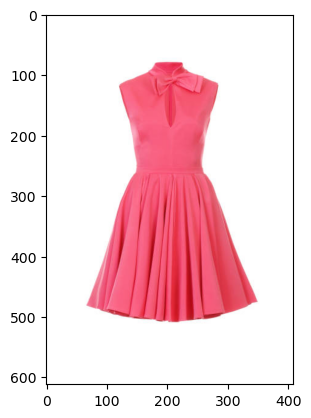

In [38]:
import matplotlib.pyplot as plt
plt.imshow(red)
plt.show()

In [39]:
from keras import backend as K
print(K.image_data_format())

channels_last
